<a href="https://colab.research.google.com/github/Frederick-Teye/ML-models/blob/main/PI_Assignment(Already_Sampled_Data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import pandas as pd
processed_ziya_data = pd.read_csv('/content/drive/MyDrive/diabetes_data/cleaned_ziya_data.csv')
processed_ziya_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,Female,56.0,0,0,No Info,37.23,6.5,80,0
1,Male,29.0,0,0,never,27.32,3.5,160,0
2,Female,26.0,0,0,No Info,27.32,4.0,145,0
3,Male,50.0,0,0,current,27.32,5.0,145,0
4,Female,56.0,0,0,never,38.48,5.7,155,1


In [18]:
processed_ziya_data.groupby(['gender', 'hypertension', 'heart_disease']).diabetes.count()

gender  hypertension  heart_disease
Female  0             0                7620
                      1                 439
        1             0                1207
                      1                 184
Male    0             0                5674
                      1                 673
        1             0                 979
                      1                 224
Name: diabetes, dtype: int64

In [19]:
processed_ziya_data.diabetes.value_counts()

,count
diabetes,
0,8500
1,8500


In [20]:
processed_ziya_data.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [21]:
processed_ziya_data.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [22]:
processed_ziya_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               17000 non-null  object 
 1   age                  17000 non-null  float64
 2   hypertension         17000 non-null  int64  
 3   heart_disease        17000 non-null  int64  
 4   smoking_history      17000 non-null  object 
 5   bmi                  17000 non-null  float64
 6   hbA1c_level          17000 non-null  float64
 7   blood_glucose_level  17000 non-null  int64  
 8   diabetes             17000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 1.2+ MB


In [23]:
processed_ziya_data.diabetes.value_counts()

,count
diabetes,
0,8500
1,8500


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report
import xgboost as xgb

X = processed_ziya_data.drop('diabetes', axis=1)
y = processed_ziya_data['diabetes']

categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])

param_distributions = {
    'xgb__n_estimators': [100, 200, 300, 500, 900],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 6, 7, 9],
    'xgb__min_child_weight': [1, 3, 5, 7],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 0.9, 1.0],
    'xgb__gamma': [0, 0.1, 0.5, 1, 5]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("Starting Baseline RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print(f"\nBest Hyperparameters Found:\n{random_search.best_params_}")

best_pipeline = random_search.best_estimator_
y_pred = best_pipeline.predict(X_test)

print("\n--- Final Baseline Model Performance ---")
print(classification_report(y_test, y_pred))

Starting Baseline RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters Found:
{'xgb__subsample': 0.6, 'xgb__n_estimators': 900, 'xgb__min_child_weight': 5, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.5, 'xgb__colsample_bytree': 0.9}

--- Final Baseline Model Performance ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1700
           1       0.90      0.91      0.91      1700

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



In [25]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("             ABSOLUTE PREDICTION COUNTS")
print("--------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

# 4. Print the standard percentage-based report
print("--- Standard Classification Report ---")
print(classification_report(y_test, y_pred))

             ABSOLUTE PREDICTION COUNTS
--------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 1533
False Positives (Accidentally flagged as Sick):    167
False Negatives (Missed actual Diabetes cases):    146
True Positives  (Correctly identified Diabetes):   1554

--- Standard Classification Report ---
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1700
           1       0.90      0.91      0.91      1700

    accuracy                           0.91      3400
   macro avg       0.91      0.91      0.91      3400
weighted avg       0.91      0.91      0.91      3400



/tmp/ipython-input-979/2353955779.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


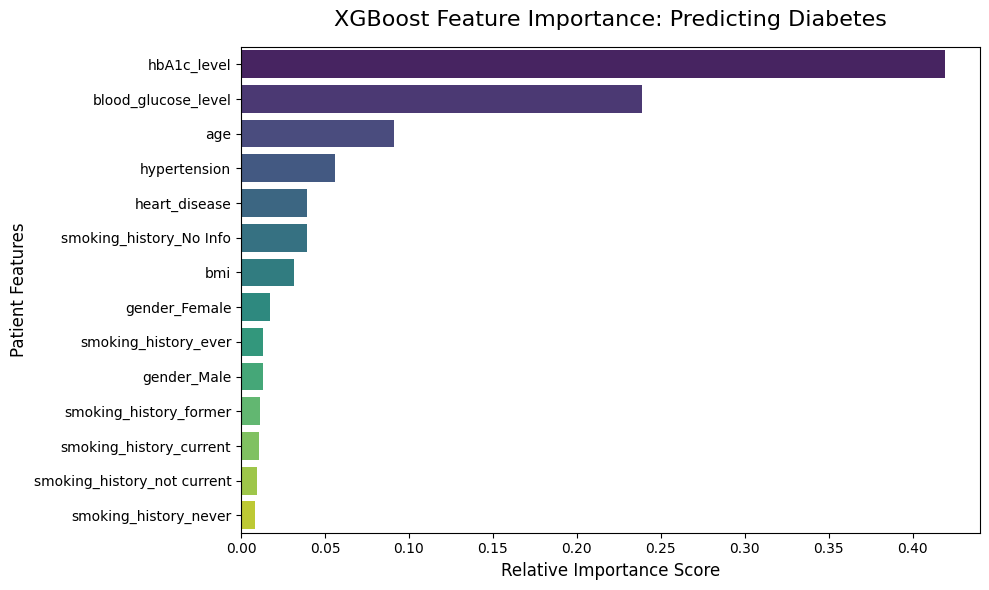

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

tuned_xgb_model = best_pipeline.named_steps['xgb']
preprocessor = best_pipeline.named_steps['preprocessor']

feature_names = preprocessor.get_feature_names_out()

clean_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

importances = tuned_xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': clean_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

plt.title("XGBoost Feature Importance: Predicting Diabetes", fontsize=16, pad=15)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Patient Features", fontsize=12)

plt.tight_layout()
plt.show()

In [27]:
processed_ziya_data = processed_ziya_data.drop(columns=['blood_glucose_level', 'hbA1c_level'])
processed_ziya_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,diabetes
0,Female,56.0,0,0,No Info,37.23,0
1,Male,29.0,0,0,never,27.32,0
2,Female,26.0,0,0,No Info,27.32,0
3,Male,50.0,0,0,current,27.32,0
4,Female,56.0,0,0,never,38.48,1


In [28]:

X = processed_ziya_data.drop('diabetes', axis=1)
y = processed_ziya_data['diabetes']

categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(eval_metric='logloss', random_state=42))
])

param_distributions = {
    'xgb__n_estimators': [100, 200, 300, 500, 900],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 6, 7, 9],
    'xgb__min_child_weight': [1, 3, 5, 7],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 0.9, 1.0],
    'xgb__gamma': [0, 0.1, 0.5, 1, 5]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='roc_auc',
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("Starting Baseline RandomizedSearchCV...")
random_search.fit(X_train, y_train)

print(f"\nBest Hyperparameters Found:\n{random_search.best_params_}")

best_pipeline = random_search.best_estimator_
y_pred = best_pipeline.predict(X_test)

print("\n--- Final Baseline Model Performance ---")
print(classification_report(y_test, y_pred))

Starting Baseline RandomizedSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters Found:
{'xgb__subsample': 0.8, 'xgb__n_estimators': 200, 'xgb__min_child_weight': 1, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.05, 'xgb__gamma': 5, 'xgb__colsample_bytree': 0.8}

--- Final Baseline Model Performance ---
              precision    recall  f1-score   support

           0       0.79      0.72      0.75      1700
           1       0.74      0.80      0.77      1700

    accuracy                           0.76      3400
   macro avg       0.76      0.76      0.76      3400
weighted avg       0.76      0.76      0.76      3400



In [29]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("             ABSOLUTE PREDICTION COUNTS")
print("--------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

# 4. Print the standard percentage-based report
print("--- Standard Classification Report ---")
print(classification_report(y_test, y_pred))

             ABSOLUTE PREDICTION COUNTS
--------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 1225
False Positives (Accidentally flagged as Sick):    475
False Negatives (Missed actual Diabetes cases):    332
True Positives  (Correctly identified Diabetes):   1368

--- Standard Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.72      0.75      1700
           1       0.74      0.80      0.77      1700

    accuracy                           0.76      3400
   macro avg       0.76      0.76      0.76      3400
weighted avg       0.76      0.76      0.76      3400



In [30]:
import pandas as pd
import numpy as np
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report
import xgboost as xgb

df_majority = processed_ziya_data[processed_ziya_data['diabetes'] == 0]
df_minority = processed_ziya_data[processed_ziya_data['diabetes'] == 1]

df_minority = shuffle(df_minority, random_state=42)
min_train_size = int(len(df_minority) * 0.8)

minority_train = df_minority.iloc[:min_train_size]
minority_test = df_minority.iloc[min_train_size:]

df_majority = shuffle(df_majority, random_state=42)

majority_train = df_majority.iloc[:min_train_size]
majority_test = df_majority.iloc[min_train_size:]

train_data = shuffle(pd.concat([majority_train, minority_train]), random_state=42)
test_data = shuffle(pd.concat([majority_test, minority_test]), random_state=42)

X_train = train_data.drop('diabetes', axis=1)
y_train = train_data['diabetes']

X_test = test_data.drop('diabetes', axis=1)
y_test = test_data['diabetes']

categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

manual_params = {
    'n_estimators': 200,
    'learning_rate': 0.1,
    'max_depth': 3,
    'min_child_weight': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 1,
    'eval_metric': 'logloss',
    'random_state': 42
}

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('xgb', xgb.XGBClassifier(**manual_params))
])

print("Training the manual model on the 50/50 classroom...")
pipeline.fit(X_train, y_train)


custom_threshold = 0.50
print(f"\nEvaluating with Custom Threshold: {custom_threshold}")

y_pred_probabilities = pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (y_pred_probabilities >= custom_threshold).astype(int)

# --- The Confusion Matrix Output ---
cm = confusion_matrix(y_test, y_pred_custom)
tn, fp, fn, tp = cm.ravel()

print("             ABSOLUTE PREDICTION COUNTS")
print("--------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred_custom))

Training the manual model on the 50/50 classroom...

Evaluating with Custom Threshold: 0.5
             ABSOLUTE PREDICTION COUNTS
--------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 1225
False Positives (Accidentally flagged as Sick):    475
False Negatives (Missed actual Diabetes cases):    320
True Positives  (Correctly identified Diabetes):   1380

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.72      0.76      1700
           1       0.74      0.81      0.78      1700

    accuracy                           0.77      3400
   macro avg       0.77      0.77      0.77      3400
weighted avg       0.77      0.77      0.77      3400



In [31]:
# --- Add the Absolute Counts back in for clinical evaluation ---
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n             ABSOLUTE PREDICTION COUNTS")
print("------------------------------------------------------")
print(f"True Negatives  (Correctly identified as Healthy): {tn}")
print(f"False Positives (Accidentally flagged as Sick):    {fp}")
print(f"False Negatives (Missed actual Diabetes cases):    {fn}")
print(f"True Positives  (Correctly identified Diabetes):   {tp}\n")

print("--- Final Tuned Bagging Model Performance ---")
print(classification_report(y_test, y_pred))


             ABSOLUTE PREDICTION COUNTS
------------------------------------------------------
True Negatives  (Correctly identified as Healthy): 786
False Positives (Accidentally flagged as Sick):    914
False Negatives (Missed actual Diabetes cases):    771
True Positives  (Correctly identified Diabetes):   929

--- Final Tuned Bagging Model Performance ---
              precision    recall  f1-score   support

           0       0.50      0.46      0.48      1700
           1       0.50      0.55      0.52      1700

    accuracy                           0.50      3400
   macro avg       0.50      0.50      0.50      3400
weighted avg       0.50      0.50      0.50      3400

